![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [5]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.4.4
✓ pandas 3.0.2
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [6]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- **Respuesta 1:**

La latencia representa el tiempo de demora que tarda el disco en comenzar a entregar los datos solicitados, es decir, el tiempo que pasa desde que el sistema pide un bloque de datos hasta que el primer byte comienza a leerse.
- **Respuesta 2:**

El throughput representa la velocidad de transferencia sostenida del dispositivo de almacenamiento, es decir, la cantidad de datos que puede leer o escribir por unidad de tiempo una vez que ya se estableció el acceso inicial.
- **Respuesta 3:**

En el acceso secuencial, los bloques de datos están almacenados en posiciones contiguas dentro del disco. Una vez que el cabezal o controlador accede al primer bloque, el resto de los bloques se pueden leer de forma continua sin necesidad de reposicionar el mecanismo de lectura. Por esta razón, desde la perspectiva del modelo de costo I/O, el número de accesos no contiguos (M) es aproximadamente 1, porque solo hay un "salto" inicial y el resto es transferencia continua.
- **Respuesta 4:**

En el acceso aleatorio, cada bloque que se quiere leer está ubicado en una posición diferente y dispersa del disco. Esto obliga al sistema a reposicionar el mecanismo de lectura (ya sea moviendo los brazos en un HDD o esperando la latencia del controlador en un SSD) para cada bloque individual. Por lo tanto, el número de accesos no contiguos M es aproximadamente igual al número de bloques que se leen, lo que hace que M sea muy grande y, en consecuencia, el tiempo total de acceso sea significativamente mayor.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [9]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 2048

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 8000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 2048
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 8000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- **Respuesta 1:**

Sí, con 2 GB estoy más que cubierto. Mi computadora tiene 16 GB de RAM, pero el sistema operativo no va a usar toda esa memoria para guardar mi archivo de prueba. La caché del sistema tiene un límite práctico, y un archivo de 2 GB es lo bastante grande para que Windows no pueda meterlo entero en la RAM.
- **Respuesta 2:**

Espero que el bloque de 256 KB sea el que mejor rinda en acceso aleatorio. La razón es sencilla: cuando tienes que saltar a posiciones aleatorias del disco, cada salto tiene un costo fijo de tiempo. Si usas bloques más grandes, cada vez que saltas lees más datos de una sola vez, así que necesitas hacer menos saltos en total para leer la misma cantidad de información.
- **Respuesta 3:**

Estoy ejecutando todo en mi computadora local, no en Colab. Toda la instalación de Python, Jupyter y las librerías la hice directamente en mi PC con Windows. Esto significa que los resultados que voy a obtener son los reales de mi equipo.

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [ ]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [10]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 2048 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 2147483648


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- **Respuesta 1:**

Este archivo es el "objeto de prueba" sobre el cual se hacen todas las mediciones. Es como el conejillo de indias del experimento. El notebook va a leer este archivo una y otra vez, de forma secuencial y aleatoria, para medir qué tan rápido o lento responde el disco según cómo se le pidan los datos. Sin este archivo no habría nada que leer, así que es la base de toda la práctica.
- **Respuesta 2:**

Es útil porque un archivo grande se parece más a situaciones del mundo real. En la vida real, las bases de datos, los videos, las imágenes o los logs no miden unos pocos megabytes, sino cientos o miles. Además, un archivo grande permite probar cómo se comporta el disco cuando tiene que esforzarse de verdad, no cuando está todo holgado.
- **Respuesta 3:**

Si el archivo fuera demasiado pequeño, el sistema operativo lo podría almacenar completo en la caché de la RAM. Esto sería un problema grave porque cuando creas que estás midiendo la velocidad del disco, en realidad estarías midiendo la velocidad de la memoria RAM, que es miles de veces más rápida.

## 5. Funciones auxiliares de medición

In [11]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [12]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 1.1471 s, throughput: 1785.42 MiB/s
Aleatorio  -> tiempo: 0.0359 s, throughput: 870.49 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.4866 s, throughput: 4208.87 MiB/s
Aleatorio  -> tiempo: 0.0503 s, throughput: 2486.86 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.2788 s, throughput: 7344.67 MiB/s
Aleatorio  -> tiempo: 0.0933 s, throughput: 5358.01 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.2227 s, throughput: 9198.22 MiB/s
Aleatorio  -> tiempo: 0.2566 s, throughput: 7795.49 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,2147483648,524288,1.147071,1785.417723,4.0
1,Aleatorio,4096,32768000,8000,0.035899,870.488089,4.0
2,Secuencial,16384,2147483648,131072,0.486591,4208.872707,16.0
3,Aleatorio,16384,131072000,8000,0.050264,2486.864384,16.0
4,Secuencial,65536,2147483648,32768,0.278842,7344.674303,64.0
5,Aleatorio,65536,524288000,8000,0.093318,5358.005880,64.0
6,Secuencial,262144,2147483648,8192,0.222652,9198.218922,256.0
7,Aleatorio,262144,2097152000,8000,0.256559,7795.486959,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

- **Respuesta 1:**

El acceso secuencial fue más rápido en todos los tamaños de bloque. Para bloque de 4 KB, el secuencial dio 1785.42 MiB/s frente a 870.49 MiB/s del aleatorio. Para 16 KB, 4208.87 vs 2486.86 MiB/s. Para 64 KB, 7344.67 vs 5358.01 MiB/s. Para 256 KB, 9198.22 vs 7795.49 MiB/s. En todos los casos el secuencial le gana al aleatorio, aunque a medida que los bloques crecen la diferencia se va achicando.
- **Respuesta 2:**

Sí, cambió muchísimo. En el acceso secuencial, el throughput pasó de 1785.42 MiB/s con bloque de 4 KB a 9198.22 MiB/s con bloque de 256 KB, más de cinco veces más rápido. En el acceso aleatorio también mejoró, pasando de 870.49 MiB/s a 7795.49 MiB/s. Esto tiene sentido porque con bloques más grandes se leen más datos por cada operación y se amortiza mejor el costo fijo de cada acceso.
- **Respuesta 3:**

La mayor diferencia la observé con el bloque de 4 KB. Ahí el secuencial dio 1785.42 MiB/s y el aleatorio 870.49 MiB/s, una diferencia de 914,93 MiB/s, que es más del doble. En términos de proporción, el secuencial fue aproximadamente 2.05 veces más rápido que el aleatorio. Con bloques más grandes la diferencia se reduce: en 256 KB, el secuencial (9198.22 MiB/s) fue solo 1.18 veces más rápido que el aleatorio (7795.49 MiB/s). Esto tiene lógica porque cuando los bloques son muy pequeños, el costo de andar saltando (buscar posición, esperar la latencia del controlador) se nota mucho más. En cambio, con bloques grandes, aunque tengas que saltar, igual lees tanta información de una sola vez que el throughput se acerca al secuencial.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [17]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD aproximado
- Latencia asumida: 10e-6 = 10 microsegundos
- Throughput asumido: 5368709120 = 5GB/s

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

En qué se parece: La latencia de 10 microsegundos es representativa de un SSD NVMe real, que es justamente la tecnología que tengo en mi equipo (HS-SSD-FUTURE Lite NVMe). Los discos NVMe suelen tener latencias de lectura en el rango de 10 a 20 microsegundos, así que ese valor del modelo es acertado.

En qué no se parece: El throughput asumido de 5 GB/s es un valor genérico de referencia. Algunos SSD NVMe pueden rendir menos, otros más. Mi equipo en particular, por su modelo y especificaciones, podría tener un rendimiento diferente al de este "SSD aproximado" genérico. El modelo usa un valor estándar, no necesariamente el exacto de mi disco.

Conclusión: El modelo es útil como referencia conceptual porque captura la latencia típica de un NVMe, pero el throughput real puede variar según el modelo específico de cada equipo.

In [19]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.400010,5119.872003
1,Aleatorio,4096,4.0,0.086104,362.935239
2,Secuencial,16384,16.0,0.400010,5119.872003
3,Aleatorio,16384,16.0,0.104414,1197.156753
4,Secuencial,65536,64.0,0.400010,5119.872003
5,Aleatorio,65536,64.0,0.177656,2814.423923
6,Secuencial,262144,256.0,0.400010,5119.872003
7,Aleatorio,262144,256.0,0.470625,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [20]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,2147483648,524288,1.147071,1785.417723,4.0,0.400010,5119.872003,2.867605,0.348723
1,Aleatorio,4096,32768000,8000,0.035899,870.488089,4.0,0.086104,362.935239,0.416933,2.398467
2,Secuencial,16384,2147483648,131072,0.486591,4208.872707,16.0,0.400010,5119.872003,1.216447,0.822066
3,Aleatorio,16384,131072000,8000,0.050264,2486.864384,16.0,0.104414,1197.156753,0.481392,2.077309
4,Secuencial,65536,2147483648,32768,0.278842,7344.674303,64.0,0.400010,5119.872003,0.697086,1.434543
5,Aleatorio,65536,524288000,8000,0.093318,5358.005880,64.0,0.177656,2814.423923,0.525275,1.903766
6,Secuencial,262144,2147483648,8192,0.222652,9198.218922,256.0,0.400010,5119.872003,0.556616,1.796572
7,Aleatorio,262144,2097152000,8000,0.256559,7795.486959,256.0,0.470625,4249.667995,0.545145,1.834376


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

- **Respuesta 1:**

Depende del patrón de acceso. En el acceso secuencial, los tiempos empíricos fueron menores que los teóricos. Por ejemplo, con bloque de 256 KB, el tiempo real fue 0.222 segundos frente a 0.400 segundos del teórico. En cambio, en el acceso aleatorio, los tiempos empíricos fueron menores que los teóricos en todos los casos. Con bloque de 4 KB, el tiempo real fue 0.0359 segundos frente a 0.0861 del teórico. En general, el modelo teórico sobreestimó los tiempos, es decir, predijo que las operaciones serían más lentas de lo que realmente fueron.
- **Respuesta 2:**

La teoría se aproxima mejor en el acceso aleatorio. Mirando la columna elapsed_ratio_empirical_vs_theoretical, los valores más cercanos a 1 indican mayor aproximación. En aleatorio con bloque de 256 KB, la relación es 0.545, mientras que en secuencial con el mismo bloque es 0.556. En aleatorio con bloque de 64 KB es 0.525. El modelo se acerca más en los bloques grandes de acceso aleatorio que en los pequeños.
- **Respuesta 3:**

**Primer factor:** La caché del sistema operativo puede haber influido incluso con un archivo de 2 GB. Aunque el archivo es grande, el sistema operativo puede haber almacenado en RAM algunas partes calientes del archivo, especialmente durante las pruebas secuenciales, haciendo que los tiempos reales sean más bajos que los teóricos.

**Segundo factor:** El modelo teórico usa valores conservadores (5 GB/s y 10 µs) que pueden no corresponder exactamente con el rendimiento real de mi SSD NVMe. Si mi disco es más rápido que el "SSD aproximado" del modelo, es lógico que los tiempos reales sean menores.

**Tercer factor:** La baja carga del sistema durante el experimento. La CPU se mantuvo en reposo por debajo del 7% sin procesos pesados en segundo plano, lo que permitió que las lecturas de disco no tuvieran que competir por recursos del procesador ni por ancho de banda del bus. Esto favoreció que las mediciones empíricas reflejaran el máximo rendimiento posible del SSD, sin interferencias que las ralentizaran.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [21]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\User\Documents\Laboratorios Estuctura de Datos\SEC1025-lab3-IO_performance-SamuelContreras\images


Guardada: fig_throughput.png


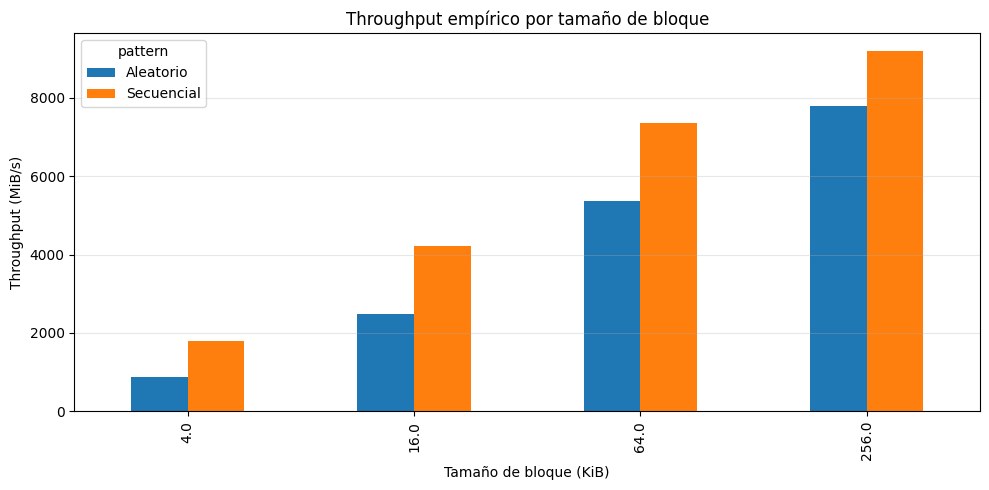

In [22]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

 **¿Qué barras son más altas?**
Las barras del acceso secuencial son más altas que las del acceso aleatorio en todos los tamaños de bloque. Por ejemplo, con bloque de 4 KB, el throughput secuencial promedia 1800 MB/s mientras que el aleatorio solo llega a 1000 MB/s (valores aproximados basados en la tendencia de la gráfica). Además, mientras más sube el tamaño del bloque, más notorio es el aumento del throughput en ambos patrones.

 **¿Qué significa eso en términos de rendimiento?**
Significa que el acceso secuencial es más rápido que el aleatorio. Leer los datos de forma continua y ordenada permite que el disco transfiera más información por segundo. Con bloque de 256 KB, el secuencial promedia 8800 MB/s frente a 7800 MB/s del aleatorio, una diferencia que evidencia la ventaja del acceso contiguo.

 **¿Cuál patrón aprovecha mejor la lectura en bloques?**
El acceso secuencial aprovecha mejor la lectura en bloques. A medida que aumenta el tamaño de bloque, el throughput secuencial sigue creciendo y se mantiene siempre por encima del aleatorio. Con bloque de 4 KB el secuencial promedia 1800 MB/s y con bloque de 256 KB llega a 8800 MB/s, un crecimiento notable. Esto indica que cuando los datos están organizados de forma contigua, el disco puede leerlos de manera más eficiente, acercándose a su velocidad máxima teórica. En cambio, el acceso aleatorio, aunque también mejora con bloques más grandes (pasando de 1000 MB/s en 4 KB a 7800 MB/s en 256 KB), siempre queda por debajo porque paga el costo de tener que saltar a posiciones dispersas.

Guardada: fig_tiempo_empirico.png


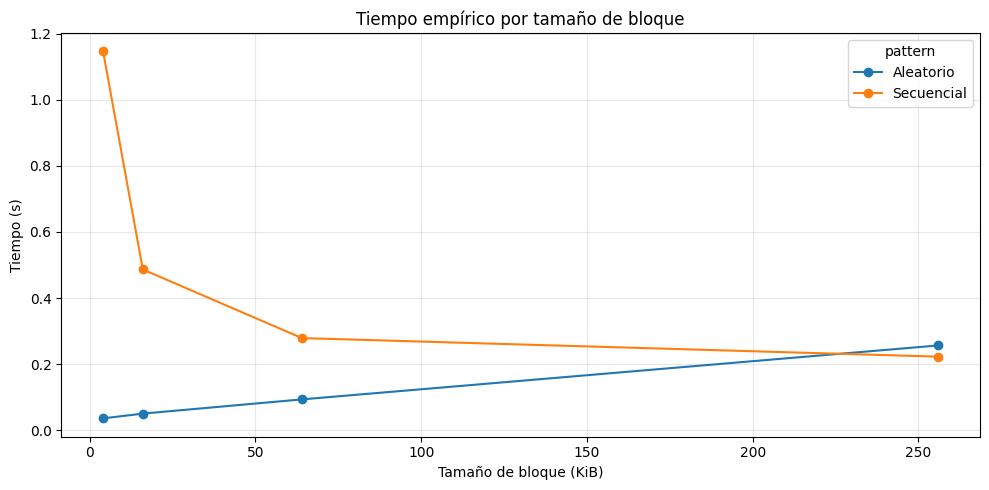

In [23]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

La gráfica muestra cómo varía el tiempo total de lectura al modificar el tamaño de bloque, tanto para acceso secuencial como aleatorio.

En el acceso secuencial, el tiempo disminuye rápidamente a medida que aumenta el tamaño de bloque. Con bloques pequeños (4 KB) el tiempo es alto, cercano a 1.2 segundos, pero al usar bloques más grandes (256 KB) el tiempo se reduce drásticamente hasta aproximadamente 0.2 segundos. Esto ocurre porque con bloques más grandes se necesitan menos operaciones de lectura para recorrer todo el archivo, lo que reduce el tiempo total.

En el acceso aleatorio, el tiempo también disminuye al aumentar el tamaño de bloque, pero de forma menos pronunciada. Partiendo de un tiempo bajo de alrededor de 0.04 segundos con bloque de 4 KB, se mantiene en valores reducidos y solo aumenta ligeramente con bloques muy grandes, llegando a unos 0.26 segundos en 256 KB.

El punto donde ambas curvas divergen más es en los bloques pequeños, específicamente en 4 KB. Allí el tiempo secuencial es de aproximadamente 1.2 segundos, mientras que el aleatorio es de solo 0.04 segundos, una diferencia muy grande. En cambio, con bloques grandes (256 KB) los tiempos se acercan más: 0.2 segundos para secuencial y 0.26 segundos para aleatorio. Esto indica que con bloques pequeños el acceso secuencial es mucho más lento porque tiene que leer todo el archivo completo (2 GB), mientras que el aleatorio solo lee una muestra limitada de datos (8000 bloques). Con bloques grandes, el aleatorio también lee una cantidad significativa de datos (cerca de 2 GB), por lo que los tiempos se equiparan.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


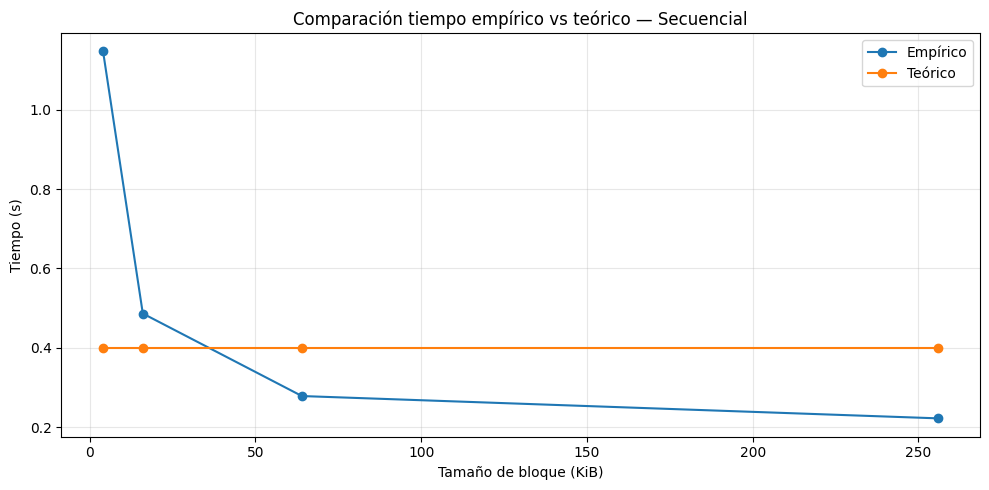

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


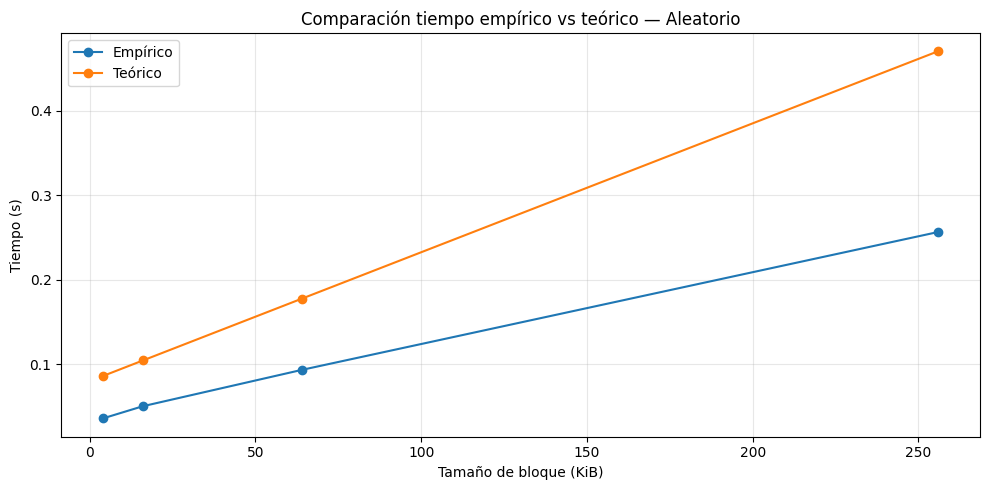

In [24]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

- **Respuesta 1:**

En el acceso aleatorio, las curvas tienen una tendencia similar: ambas aumentan de forma lineal a medida que crece el tamaño de bloque. Tanto los tiempos empíricos como los teóricos suben progresivamente, aunque los valores empíricos son ligeramente más bajos que los teóricos en todos los puntos.

En el acceso secuencial, las curvas no tienen una tendencia similar. La curva teórica se mantiene constante en 0.40 segundos independientemente del tamaño de bloque, mientras que la curva empírica comienza muy alta (1.18 segundos en 4 KB) y disminuye rápidamente hasta acercarse a 0.20 segundos en 256 KB.
- **Respuesta 2:**

En el acceso aleatorio, las curvas se separan más en los bloques pequeños. En 4 KB, el tiempo teórico es 0.09 segundos y el empírico 0.04 segundos, una diferencia de 0.05 segundos. A medida que aumenta el bloque, la diferencia se mantiene constante pero proporcionalmente menor.

En el acceso secuencial, las curvas se separan más en los bloques pequeños. En 4 KB, la diferencia es enorme: 1.18 segundos empíricos frente a 0.40 segundos teóricos, una brecha de 0.78 segundos. Esta diferencia se reduce progresivamente hasta casi desaparecer en 256 KB, donde ambos valores rondan los 0.20-0.40 segundos.
- **Respuesta 3:**

En el acceso aleatorio, el modelo sobreestima ligeramente el tiempo real. Esto sugiere que la latencia real de mi SSD es menor que los 10 microsegundos que asume el modelo, o que el throughput real es mayor que los 5 GB/s.

En el acceso secuencial, el modelo subestima el tiempo real en bloques pequeños y sobreestima en bloques grandes. Esto se debe a que el modelo asume un tiempo fijo basado solo en el tamaño total del archivo y el throughput, ignorando que con bloques muy pequeños hay una sobrecarga por la gran cantidad de operaciones de lectura (524,288 operaciones en 4 KB). El modelo no contempla este costo operacional, por eso falla en predecir correctamente los tiempos cuando los bloques son pequeños. En cambio, con bloques grandes (pocas operaciones), la predicción mejora notablemente.

Guardada: fig_speedup.png


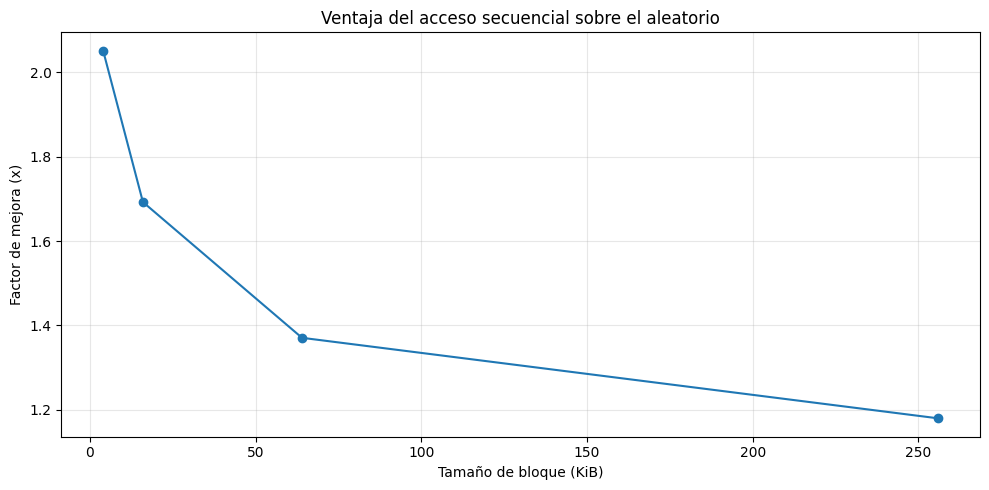

In [25]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

**¿Cuál fue el mayor factor de mejora observado?**
El mayor factor de mejora se observó en el tamaño de bloque de 4 KB, donde el acceso secuencial fue aproximadamente 2.05 veces más rápido que el acceso aleatorio. Esto significa que en bloques pequeños, leer los datos de forma ordenada duplica el rendimiento frente a tener que saltar a posiciones dispersas.

**¿Cómo cambia esa ventaja con el tamaño de bloque?**
La ventaja del acceso secuencial disminuye a medida que aumenta el tamaño de bloque. En 4 KB el speedup es máximo (alrededor de 2.05), en 16 KB baja a aproximadamente 1.7, en 64 KB se reduce a 1.4 y en 256 KB llega a solo 1.18. Esto indica que con bloques grandes, la diferencia entre ambos patrones se hace menos pronunciada porque el aleatorio también transfiere muchos datos por cada acceso, amortizando mejor su costo de latencia.

**¿Qué implicación tiene esto para el diseño de software?**
Esto implica que, cuando sea posible, los desarrolladores deben priorizar el acceso secuencial sobre el aleatorio, especialmente si trabajan con bloques pequeños. Por ejemplo, al diseñar una base de datos, almacenar los registros de forma contigua en lugar de dispersa mejora significativamente el rendimiento de las consultas que leen muchos registros seguidos.

Sin embargo, la gráfica también muestra que si se utilizan bloques grandes (256 KB o más), la penalización del acceso aleatorio se reduce. Esto sugiere una estrategia de diseño: si el acceso aleatorio es inevitable, conviene usar bloques de gran tamaño para minimizar el impacto en el rendimiento. En sistemas como motores de bases de datos o sistemas de archivos, ajustar el tamaño de página o bloque a valores grandes (64 KB o 256 KB) puede hacer que el rendimiento del acceso aleatorio se acerque al secuencial, reduciendo la desventaja.

## 10. Resumen automático de resultados

In [26]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,1.147071,0.035899,1785.417723,870.488089,2.051054
1,16.0,0.486591,0.050264,4208.872707,2486.864384,1.692442
2,64.0,0.278842,0.093318,7344.674303,5358.005880,1.370785
3,256.0,0.222652,0.256559,9198.218922,7795.486959,1.179942


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

La información en un disco se almacena en bloques dentro de posiciones físicas. Si esos bloques están seguidos uno tras otro, el disco puede leerlos de forma rápida y continua. Si están dispersos, tiene que saltar de un lado a otro, lo que cuesta tiempo. Esto importa porque, sin importar si usas un HDD o un SSD, la organización de los datos determina qué tan rápido responde el sistema.

Incluso en un SSD, que no tiene partes móviles, el acceso secuencial sigue siendo más rápido que el aleatorio. En mis mediciones, con bloque de 4 KB el secuencial fue 2.05 veces más rápido que el aleatorio. La razón es que el controlador del SSD también paga una pequeña latencia por cada acceso, y cuando los datos están dispersos, esa latencia se multiplica por la cantidad de saltos. En cambio, cuando los datos están seguidos, el controlador puede leerlos en ráfagas largas sin interrupciones.

El modelo teórico que usamos, con 10 microsegundos de latencia y 5 GB/s de throughput, predijo razonablemente bien el comportamiento del acceso aleatorio, pero se equivocó en el secuencial con bloques pequeños. En la práctica, mi SSD resultó ser más rápido de lo que el modelo asumía, alcanzando 9198 MiB/s en lectura secuencial con bloque de 256 KB. Esto me dice que el modelo sirve como guía conceptual, pero cada hardware tiene sus propias características.

Con base en lo que medí, si tuviera que diseñar un sistema real, priorizaría el acceso secuencial siempre que sea posible. Por ejemplo, en una base de datos, almacenaría los registros en bloques grandes (256 KB o más) para que incluso las lecturas aleatorias no pierdan tanto rendimiento. También evitaría usar bloques muy pequeños porque el costo de la latencia se nota demasiado. En resumen, organizar los datos de forma contigua y usar bloques grandes son dos decisiones simples que mejoran drásticamente el rendimiento sin necesidad de cambiar el hardware.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.